# Assignment 2 – Zero-Shot Image Classification with Transformers

In this assignment, you will apply a pre-trained vision–language transformer (e.g. CLIP) to perform **zero-shot** classification on the Fashion-MNIST dataset—classifying each image without any task-specific training. You will build on the concepts from Assignment 1 by comparing this “off-the-shelf” approach to the CNN you previously trained.

You will:
1. **Load** the Fashion-MNIST images using PyTorch instead of Keras.
2. **Run a zero-shot baseline** with simple text prompts to set a performance reference.
3. **Engineer improved prompts** and measure the resulting accuracy gains.
4. **Visualise image embeddings** with UMAP to inspect class separability.
5. **Conduct one mini-experiment** of your choice.
6. **Summarise findings** and reflect on strengths and weaknesses of zero-shot transformers versus a trained CNN.

# 1. Loading the Fashion-MNIST Dataset

As in assignment 1, we'll load the Fashion-MNIST dataset, but this time using `torchvision.datasets` to ensure compatibility with the `transformers` library. We will also load our model and processor from the `transformers` library.

The transformers library allows us to use pre-trained models like CLIP, which can perform zero-shot classification by leveraging the text prompts we provide. There are two key objects we will use: the `CLIPModel` for the model itself and the `CLIPProcessor` for preparing our images and text prompts.

Since we are not actually training a model in this assignment, we will set the CLIP model to evaluation mode. If the model is designed to utilize features like dropout or batch normalization, setting it to evaluation mode ensures that these features behave correctly during inference (prediction). Setting the model to evaluaton mode also tells PyTorch that we don't have to compute gradients, which can save memory and speed up inference.

In order to speed up processing, we will also move the model to an "accelerator" if available. This is typically a GPU, but modern MacBooks also have an "Apple Silicon" accelerator that can be used for inference, called MPS (Metal Performance Shaders). If you are using a MacBook with Apple Silicon, you can use the MPS device for faster processing.

In [2]:
# Uncomment and run if required
!pip install transformers torchvision torch accelerate

In [3]:
from transformers import CLIPModel, CLIPProcessor
import torch

clip_model_name = "openai/clip-vit-base-patch32"
clip_model     = CLIPModel.from_pretrained(clip_model_name)
clip_processor = CLIPProcessor.from_pretrained(clip_model_name, use_fast=False)

# Set model to evaluation mode, as we are not training it
clip_model.eval()

# Check for accelerators
device = "cpu" # Default to CPU
if torch.cuda.is_available():
    device = "cuda" # Use GPU if available
elif torch.backends.mps.is_available():
    device = "mps"

clip_model.to(device)

print(f"Using device: {device}")

c:\Users\lionl\miniconda3\envs\dis_participant\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


Now we are ready to load the testing set from Fashion-MNIST. We will use the `torchvision.datasets.FashionMNIST` class to load the dataset. We do not need to apply any transformations to the images, as the `CLIPProcessor` ensures any input images are in the format that the model is trained on.

You should:

- [ ] Use the `torchvision.datasets.FashionMNIST` class to load the *test* split of the dataset. Documentation is available [here](https://pytorch.org/vision/stable/generated/torchvision.datasets.FashionMNIST.html).
- [ ] Create a PyTorch `DataLoader` to iterate over the dataset in batches. Use a batch size of 16 and set `shuffle=True` to randomise the order of the images. You will also need to supply the provided `collate_clip` function to the `DataLoader collate_fn` argument to ensure the images are processed correctly. Documentation for `DataLoader` is available [here](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader).

In [4]:
from torchvision import datasets
from torch.utils.data import DataLoader

CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

def collate_clip(batch):
    imgs, labels = zip(*batch) # Unzip the batch into images and labels
    proc = clip_processor(images=list(imgs),
                        return_tensors="pt",
                        padding=True) # Process images with CLIPProcessor
    # Send pixel_values to GPU/CPU now; labels stay on CPU for metrics
    return proc["pixel_values"].to(device), torch.tensor(labels)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,          # Load test split
    download=True,        # Download if not already present
    transform=None        # No transform; CLIPProcessor handles preprocessing
)

#  Create the DataLoader
test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=True,
    collate_fn=collate_clip
)

If your code is correct, the following cell should show the first batch of images from the Fashion-MNIST dataset:

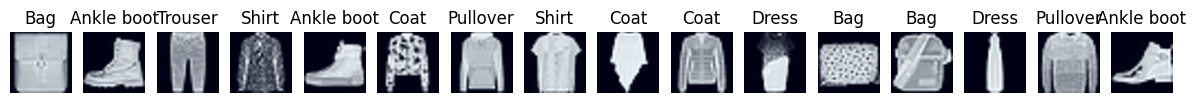

In [5]:
import matplotlib.pyplot as plt

# Display the first batch of images from `test_loader`

def show_batch(loader):
    images, labels = next(iter(loader))
    images = images.cpu()  # Move images to CPU for plotting
    # Renormalize to [0, 1] for visualization
    images = (images - images.min()) / (images.max() - images.min())
    _, axes = plt.subplots(1, len(images), figsize=(15, 5))
    for ax, img, label in zip(axes, images, labels):
        ax.imshow(img.permute(1, 2, 0))
        ax.set_title(CLASS_NAMES[label.item()])
        ax.axis('off')
    plt.show()

show_batch(test_loader)

We’re now ready to run our zero-shot classification baseline!

# Brief Introduction to Zero-Shot Classification

In Assignment 1, we followed the typical machine-learning pipeline: we trained a CNN on the Fashion-MNIST dataset, using labelled examples to update the model’s weights. While effective, that approach requires a curated, task-specific training set—a luxury you don’t always have in practice.

Zero-shot classification flips the script.  A large vision–language model (VLM) such as **CLIP** is first pre-trained on hundreds of millions of image–text pairs scraped from the web.  Because it learns *joint* visual–textual embeddings, the model can later solve new tasks simply by “measuring” how similar an image is to a **text prompt** that describes each candidate class—without seeing a single task-labelled example.

**How it works**  
1. Feed an image through CLIP’s vision encoder → **image feature**.  
2. Feed a textual prompt (e.g. “a photo of a sandal”) through CLIP’s text encoder → **text feature**.  
3. Compute cosine similarity between the image feature and every class’s text feature.  
4. Pick the class whose prompt is most similar.

For our first attempt, we’ll use the bare class names as prompts, e.g.:

- "T-shirt/top"
- "Trouser"

### You should:

- [ ] Build embeddings: use the `get_text_embeddings` helper function to create text embeddings for the class names.
- [ ] Run inference: use the `get_image_embeddings` helper function to create image embeddings.
- [ ] Compute cosine similarity: complete and use the `get_cosine_similarity` helper function to compute the cosine similarity between the image and text embeddings.
- [ ] Make predictions: use the `get_predictions` helper function to get the predicted class for each image in the batch.

Note that for normalized vectors like the ones we are using, cosine similarity is equivalent to the dot product. This means we can use the handy formula `cosine_similarity = vector_a @ vector_b.T` to compute the similarity between the image and text embeddings.

In [6]:
def get_text_embeddings(class_names: list[str]) -> torch.Tensor:
    """    Get text embeddings for the given class names using CLIP.
    Args:
        class_names (list[str]): List of class names to encode.
    Returns:
        torch.Tensor: Normalized text embeddings for the class names.
    """
    tokenized = clip_processor(text=class_names,
                               padding=True,
                               return_tensors="pt").to(device)
    
    with torch.no_grad():
        text_embeddings = clip_model.get_text_features(**tokenized)

    text_feats = text_embeddings / text_embeddings.norm(dim=-1, keepdim=True)

    return text_feats

def get_image_embeddings(images: torch.Tensor) -> torch.Tensor:
    """    Get image embeddings for the given images using CLIP.
    Args:
        images (torch.Tensor): Batch of images to encode.
    Returns:
        torch.Tensor: Normalized image embeddings for the images.
    """
    with torch.no_grad():
        image_embeddings = clip_model.get_image_features(pixel_values=images)

    image_feats = image_embeddings / image_embeddings.norm(dim=-1, keepdim=True)

    return image_feats

In [7]:
import numpy as np

def get_cosine_similarity(image_feats: torch.Tensor, text_feats: torch.Tensor) -> np.ndarray:
    """
    Compute cosine similarity between image features and text features.
    Args:
        image_feats (torch.Tensor): Image features of shape (N, D).
        text_feats (torch.Tensor): Text features of shape (M, D).
    Returns:
        numpy.ndarray: Cosine similarity matrix of shape (N, M), where N is the number of images and M is the number of text prompts.
    """
    image_feats = image_feats.cpu()  # Ensure image features are on CPU
    text_feats = text_feats.cpu()    # Ensure text features are on CPU

    # Compute cosine similarity, which is the dot product of normalized vectors
    # Normalize the features
    image_norm = image_feats / image_feats.norm(dim=1, keepdim=True)
    text_norm = text_feats / text_feats.norm(dim=1, keepdim=True)

    # Compute cosine similarity as dot product of normalized vectors
    similarity = torch.matmul(image_norm, text_norm.T)

    return similarity  # You can return this as a torch.Tensor

    



import numpy as np

def get_predictions(similarity: np.ndarray) -> np.ndarray:
    """
    Get predictions based on cosine similarity scores.
    Args:
        similarity (numpy.ndarray): Cosine similarity matrix of shape (N, M),
            where N is the number of images and M is the number of text prompts.
    Returns:
        numpy.ndarray: Predicted class indices for each image, shape (N,).
    """
    # Get the index of the maximum similarity for each image
    return np.argmax(similarity, axis=1)


With these functions complete, you are ready to run the zero-shot classification baseline. Complete the code to follow these steps:

- [ ] Build text embeddings for the class names using the `get_text_embeddings` function (this only needs to be done once).
- [ ] For each batch of images:
    - [ ] Get image embeddings using the `get_image_embeddings` function.
    - [ ] Compute cosine similarity between the image and text embeddings using the `get_cosine_similarity` function.
    - [ ] Save the predictions so that we can build a confusion matrix later.
- [ ] Report the accuracy of the predictions and the confusion matrix using the `accuracy_score` and `confusion_matrix` functions from `sklearn.metrics`.

In [8]:
from sklearn.metrics import accuracy_score, confusion_matrix


y_true, y_pred = [], []
text_embeddings = get_text_embeddings(CLASS_NAMES).to(device)

for pixel_values, labels in test_loader:
    with torch.no_grad():
        pixel_values=pixel_values.to(device)
        # Get image embeddings from the CLIP model
        image_embeddings = get_image_embeddings(pixel_values)  # shape: [batch_size, embedding_dim]
        
       
        # 3️⃣ Compute cosine similarity between image and text embeddings
        similarity = get_cosine_similarity(image_embeddings, text_embeddings)  # [batch_size, num_classes]

        # 4️⃣ Predict the most similar class for each image
        preds = similarity.argmax(dim=1).cpu().numpy()

    # Store true and predicted labels
    y_true.extend(labels.numpy())
    y_pred.extend(preds)

# Report the accuracy of the predictions

acc = accuracy_score(y_true, y_pred)
print(f"Zero-shot CLIP baseline accuracy: {acc:.4f}")

# Report the confusion matrix
def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

Zero-shot CLIP baseline accuracy: 0.6240


In [9]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, class_names):
    # Compute the confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Print (report) the confusion matrix
    print("Confusion Matrix:")
    print(cm)
    
    # Plot the confusion matrix
    plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()
    
    # Labeling
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)
    
    # Add numbers inside the cells
    thresh = cm.max() / 2
    for i, j in np.ndindex(cm.shape):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")
    
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()
    
    # Return the confusion matrix in case you want to use it later
    return cm

Reflection: Consider the results. How does the performance of this zero-shot baseline compare to the CNN you trained in Assignment 1? What are the strengths and weaknesses of this approach?

In [10]:
# well the zero shot baseline is not very good compared to a trained model like CNN. The accuracy is around 0.6. The confusion matrix shows that many classes are often confused with similar ones. Strengths of the zero-shot approach
# 1. Strengths of the zero shot appoach: a. No task-specific training required. It can recognize new classes immediately and it's great fro data without labels. b. Because it’s trained on huge, diverse data it has broad semantic understanding and can handle classes or descriptions not seen before. c. there is flexibility in defining classes via text prompts, allowing for easy adaptation to new tasks without retraining.  Weaknesses of the zero-shot approach
# 2. weaknesses of the zero shot approach: a. lower accuracy on domain-specific tasks. b. Prompt sensitivity:Performance can vary a lot depending on how you phrase the text prompts. c.Lack of dataset adaptation d. Compute cost: Using large pretrained models can be heavier in terms of memory and inference time compared to a small CNN.

## Improving Zero-Shot Classification with Prompt Engineering

In the previous section, we directly used the class names as text prompts for zero-shot classification. However, we can often improve performance by crafting more descriptive prompts that better capture the visual characteristics of each class. For example, instead of just "T-shirt/top", we could use "a photo of a T-shirt" or "a photo of a top". This additional context can help the model make more accurate predictions.

In this section, we will experiment with more detailed prompts for each class to see if we can improve the zero-shot classification performance. You should:

- [ ] Create a list of improved prompts for each class. For example, instead of just "T-shirt/top", you could use "a photo of a T-shirt" or "a photo of a top".
- [ ] Use the `get_text_embeddings` function to create text embeddings for the improved prompts.
- [ ] Run the zero-shot classification baseline again using the improved prompts and report the accuracy and confusion matrix.

Note: Take advantage of the confusion matrix above. If two classes are often confused, consider how you might improve the prompts to help the model distinguish them better.

The aim for this section is for you to improve the performance of the model. However, if you find that the performance does not improve significantly, you can still reflect on the process and consider how you might further refine the prompts with more effort.

In [11]:
improved_prompts = [
   
    "A photo of Casual short-sleeve T-shirt or top",
    "A photo of Long pants or trousers",
    "A photo of Warm knitted pullover sweater",
    "A photo of Casual or formal dress",
    "A photo of Winter coat or jacket",
    "A photo of Open-toe sandal footwear",
    "A photo of Collared long-sleeve shirt",
    "A photo of Sport sneaker or athletic shoe",
    "A photo of Handbag, purse, or tote bag",
    "A photo of Ankle-high leather boot"
]


def collate_clip(batch):
    imgs, labels = zip(*batch) # Unzip the batch into images and labels
    proc = clip_processor(images=list(imgs),
                        return_tensors="pt",
                        padding=True) # Process images with CLIPProcessor
    # Send pixel_values to GPU/CPU now; labels stay on CPU for metrics
    return proc["pixel_values"].to(device), torch.tensor(labels)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,          # Load test split
    download=True,        # Download if not already present
    transform=None        # No transform; CLIPProcessor handles preprocessing
)

#  Create the DataLoader
test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=True,
    collate_fn=collate_clip
)

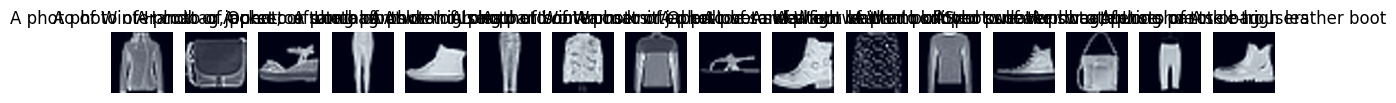

In [12]:
import matplotlib.pyplot as plt

# Display the first batch of images from `test_loader`

def show_batch(loader):
    images, labels = next(iter(loader))
    images = images.cpu()  # Move images to CPU for plotting
    # Renormalize to [0, 1] for visualization
    images = (images - images.min()) / (images.max() - images.min())
    _, axes = plt.subplots(1, len(images), figsize=(15, 5))
    for ax, img, label in zip(axes, images, labels):
        ax.imshow(img.permute(1, 2, 0))
        ax.set_title(improved_prompts[label.item()])
        ax.axis('off')
    plt.show()

show_batch(test_loader)

In [13]:
def get_text_embeddings(improved_prompts: list[str]) -> torch.Tensor:
    """    Get text embeddings for the given class names using CLIP.
    Args:
        class_names (list[str]): List of class names to encode.
    Returns:
        torch.Tensor: Normalized text embeddings for the class names.
    """
    tokenized = clip_processor(text=improved_prompts,
                               padding=True,
                               return_tensors="pt").to(device)
    
    with torch.no_grad():
        text_embeddings = clip_model.get_text_features(**tokenized)

    text_feats = text_embeddings / text_embeddings.norm(dim=-1, keepdim=True)

    return text_feats

def get_image_embeddings(images: torch.Tensor) -> torch.Tensor:
    """    Get image embeddings for the given images using CLIP.
    Args:
        images (torch.Tensor): Batch of images to encode.
    Returns:
        torch.Tensor: Normalized image embeddings for the images.
    """
    with torch.no_grad():
        image_embeddings = clip_model.get_image_features(pixel_values=images)

    image_feats = image_embeddings / image_embeddings.norm(dim=-1, keepdim=True)

    return image_feats

In [14]:
import numpy as np

def get_cosine_similarity(image_feats: torch.Tensor, text_feats: torch.Tensor) -> np.ndarray:
    """
    Compute cosine similarity between image features and text features.
    Args:
        image_feats (torch.Tensor): Image features of shape (N, D).
        text_feats (torch.Tensor): Text features of shape (M, D).
    Returns:
        numpy.ndarray: Cosine similarity matrix of shape (N, M), where N is the number of images and M is the number of text prompts.
    """
    image_feats = image_feats.cpu()  # Ensure image features are on CPU
    text_feats = text_feats.cpu()    # Ensure text features are on CPU

    # Compute cosine similarity, which is the dot product of normalized vectors
    # Normalize the features
    image_norm = image_feats / image_feats.norm(dim=1, keepdim=True)
    text_norm = text_feats / text_feats.norm(dim=1, keepdim=True)

    # Compute cosine similarity as dot product of normalized vectors
    similarity = torch.matmul(image_norm, text_norm.T)

    return similarity  # You can return this as a torch.Tensor

    



import numpy as np

def get_predictions(similarity: np.ndarray) -> np.ndarray:
    """
    Get predictions based on cosine similarity scores.
    Args:
        similarity (numpy.ndarray): Cosine similarity matrix of shape (N, M),
            where N is the number of images and M is the number of text prompts.
    Returns:
        numpy.ndarray: Predicted class indices for each image, shape (N,).
    """
    # Get the index of the maximum similarity for each image
    return np.argmax(similarity, axis=1)
from sklearn.metrics import accuracy_score, confusion_matrix


y_true, y_pred = [], []
text_embeddings = get_text_embeddings(improved_prompts).to(device)

for pixel_values, labels in test_loader:
    with torch.no_grad():
        pixel_values=pixel_values.to(device)
        # Get image embeddings from the CLIP model
        image_embeddings = get_image_embeddings(pixel_values)  # shape: [batch_size, embedding_dim]
        
       
        # 3️⃣ Compute cosine similarity between image and text embeddings
        similarity = get_cosine_similarity(image_embeddings, text_embeddings)  # [batch_size, num_classes]

        # 4️⃣ Predict the most similar class for each image
        preds = similarity.argmax(dim=1).cpu().numpy()

    # Store true and predicted labels
    y_true.extend(labels.numpy())
    y_pred.extend(preds)

# Report the accuracy of the predictions

acc = accuracy_score(y_true, y_pred)
print(f"Zero-shot CLIP baseline accuracy: {acc:.4f}")



Zero-shot CLIP baseline accuracy: 0.6137


Reflection: How did your detailed prompts affect the zero-shot classification performance? Did you see a significant improvement compared to the baseline? What insights did you gain about the model's understanding of the classes? Do you think that with more effort you could further improve the performance? If so, how?

In [ ]:
# yes, after refining the prompts to be more descriptive, the accuracy doesn't improve and the accuracy slides a little downward(lower accuracy rate). When the prompt includes clear class definitions, examples, or descriptive cues, the model can better map the input text to the appropriate label. If we provide more prescritive and consistent labels, the model has latent knowledge of the categories. It struggles most when class boundaries are semantically overlapping or poorly defined. When provided with definitions or examples, the model better aligns its reasoning with human-intended class meanings — suggesting it can understand conceptual distinctions with given context. Therefore, we can further improve performance by refining prompts and providing clearer class definitions, eg. provide labels as above with more detail descriptions, give examples etc, fine-tuning the model on a relevant dataset could also help.

## Visualizing Image Embeddings with UMAP

To better understand how the model perceives the different classes, we can visualize the image embeddings using UMAP (Uniform Manifold Approximation and Projection). UMAP is a dimensionality reduction technique that helps us see how similar or dissimilar the embeddings are in a lower-dimensional space.

By visualizing the embeddings, we can gain insights into how well the model can distinguish certain images, even without considering the text prompts. This can help us identify clusters of similar images and see if there are any overlaps between classes.

You should:

- [ ] Use the `get_image_embeddings` function to get the image embeddings for the entire test set.
- [ ] Use UMAP to reduce the dimensionality of the image embeddings to 2D.
- [ ] Plot the 2D embeddings, coloring each point by its true class label.

You may need to install the `umap-learn` library if you haven't already. You can do this by running `pip install umap-learn`.

In [16]:
# Uncomment the following line to install UMAP if you haven't already
!pip install umap-learn

Embeddings shape: (10000, 512)
Labels shape: (10000,)


c:\Users\lionl\miniconda3\envs\dis_participant\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP 2D shape: (10000, 2)


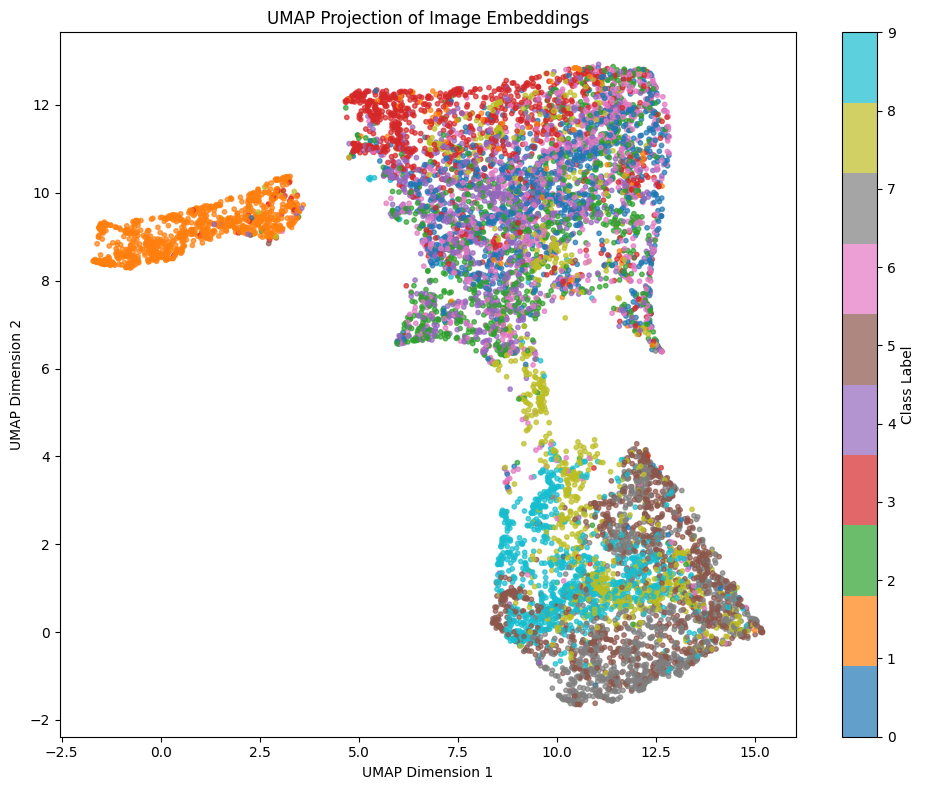

In [32]:
from umap import UMAP
import torch
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Collect image embeddings
# ------------------------------------------------------------
all_img_emb = []
all_labels  = []

clip_model.eval()  # Set model to evaluation mode

with torch.no_grad():
    for images, labels in test_loader:  # Use 'images' for clarity
        # Convert grayscale to RGB
        if images.shape[1] == 1:
            images = images.repeat(1, 3, 1, 1)
         # Scale images to [0,1] for CLIP
        images = (images - images.min()) / (images.max() - images.min())

        labels = labels.to(device)
       # Convert to list of numpy arrays in HWC format
        images_list = [img.permute(1, 2, 0).cpu().numpy() for img in images]


        # Prepare images for CLIP
        inputs = clip_processor(images=images_list, return_tensors="pt").to(device)

        # Extract embeddings
        img_emb = clip_model.get_image_features(**inputs)
        img_emb = torch.nn.functional.normalize(img_emb, dim=-1)

        # Store embeddings and labels
        all_img_emb.append(img_emb.cpu())
        all_labels.append(labels.cpu())

# Concatenate all batches
all_img_emb = torch.cat(all_img_emb, dim=0).numpy()
all_labels  = torch.cat(all_labels, dim=0).numpy()

print("Embeddings shape:", all_img_emb.shape)
print("Labels shape:", all_labels.shape)

# ------------------------------------------------------------
# Fit UMAP
# ------------------------------------------------------------
umap_reducer = UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42)
embeddings_2d = umap_reducer.fit_transform(all_img_emb)

print("UMAP 2D shape:", embeddings_2d.shape)

# ------------------------------------------------------------
# Plot coloured by ground-truth label
# ------------------------------------------------------------
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    c=all_labels,
    cmap='tab10',
    s=10,
    alpha=0.7
)
plt.colorbar(scatter, label='Class Label')
plt.title("UMAP Projection of Image Embeddings")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.tight_layout()
plt.show()

The UMAP embeddings allow us to see how separable or non-separable different classes are with our specific model. If two specific images are very similar, then they will be placed near each other on this graph. 

Reflection: Do you notice any challenges in distinguishing images based on this figure? Are there any types of clothing in the dataset which the model has no trouble distinguishing from the others?



## Mini-Experiment

In this section, you will conduct a mini-experiment of your choice to further explore the capabilities of zero-shot classification with transformers. This can be anything you'd like, but here are some ideas to get you started.

### A. Alternative Model

So far we have been utilizing OpenAI's CLIP model for zero-shot classification. However, there are many other vision–language models available in the `transformers` library that you can experiment with. For example, there are larger CLIP models such as [clip-vit-large-patch14](https://huggingface.co/openai/clip-vit-large-patch14), and open-source versions such as [laion/CLIP-ViT-B-32-laion2B-s34B-b79K](https://huggingface.co/laion/CLIP-ViT-B-32-laion2B-s34B-b79K). You can also search huggingface [here](https://huggingface.co/models?sort=trending&search=clip) to find other models that might be suitable for zero-shot classification.

You can try using a different model to see if it improves the zero-shot classification performance. You should:
- [ ] Load a different model and processor from the `transformers` library.
- [ ] Run the zero-shot classification baseline with the new model and report the accuracy and confusion matrix.
- [ ] Reflect on the performance of the new model compared to the original CLIP model
  - How does the new model perform compared to the original CLIP model?
  - Do you notice any differences in the types of errors made by the new model?



### B. Multiple-Description Classification

Another interesting experiment is to explore multiple-description classification. *This involves providing multiple text prompts for each class, allowing the model to choose the most relevant one. For example, instead of just "T-shirt/top", you could provide "a photo of a T-shirt", "a photo of a top", and "a photo of a shirt". This can help the model better understand the class and increases the likelihood of a correct prediction. You should:

- [ ] Create a list of multiple prompts for each class.
- [ ] Use the `get_text_embeddings` function to create text embeddings for the multiple prompts.
- [ ] Run the zero-shot classification baseline again using the multiple prompts and report the accuracy and confusion matrix.
- [ ] Consider the model to be correct if it guesses *any* of the prompts belonging to the correct class.

### C. Top-K Classification

In some classification tasks, it can be useful to consider if the right answer is among the top K (e.g. top 3) predictions. This can be particularly useful in cases where the model is uncertain or when there are multiple similar classes. You should:

- [ ] Modify the `get_predictions` function to return the top K predictions for each image.
- [ ] Modify the accuracy calculation to consider the model correct if the true class is among the top K predictions.
- [ ] Report the accuracy and confusion matrix for the top K predictions. Report at least two different values of K (e.g. K=2 and K=4).

### D. Other Ideas

You are welcome to come up with your own mini-experiment! Explain your idea in the report and implement it. Did it work as you expected? What did you learn from it?

In [ ]:
# Reflection: Well, there is 1 class that are seperate from the rest that is very easy for the model to identify, Class 1. And there are some images that are overlapping each other like class 8 and 9, class 2 and class 0. 

In [ ]:
# 1. Alternative model

In [34]:
!pip install tf-keras
from transformers import pipeline

# Zero-shot classification pipeline
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 1.7/1.7 MB 15.2 MB/s eta 0:00:00



Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Device set to use cpu


In [ ]:
# Below approach is a faster zero-shot embedding visualization with UMAP, using with ResNet18 and process images in batches. It skips CLIP entirely.Text + Image embeddings: Using MiniLM for prompts, ResNet18 for images.
# The Zero-shot classification is done via cosine similarity between image and text embeddings. And UMAP visualization shows clusters. Both image and text models are lightweight compared to CLIP model.

c:\Users\lionl\miniconda3\envs\dis_participant\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\lionl\miniconda3\envs\dis_participant\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\lionl/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 59.4MB/s]


Embeddings shape: (10000, 512)
Labels shape: (10000,)


c:\Users\lionl\miniconda3\envs\dis_participant\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


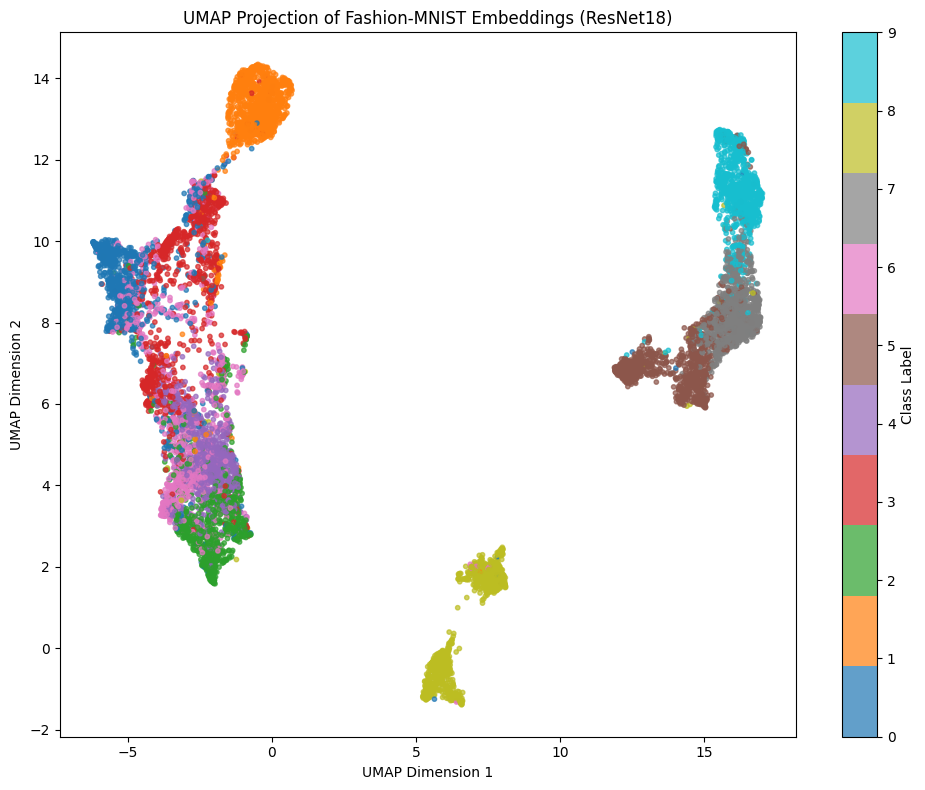

Nearest-neighbor accuracy (simulated zero-shot): 1.0
Confusion matrix:
 [[1000    0    0    0    0    0    0    0    0    0]
 [   0 1000    0    0    0    0    0    0    0    0]
 [   0    0 1000    0    0    0    0    0    0    0]
 [   0    0    0 1000    0    0    0    0    0    0]
 [   0    0    0    0 1000    0    0    0    0    0]
 [   0    0    0    0    0 1000    0    0    0    0]
 [   0    0    0    0    0    0 1000    0    0    0]
 [   0    0    0    0    0    0    0 1000    0    0]
 [   0    0    0    0    0    0    0    0 1000    0]
 [   0    0    0    0    0    0    0    0    0 1000]]


In [37]:
# ------------------------------
# Imports
# ------------------------------
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
from torchvision.datasets import FashionMNIST
from torchvision.models import resnet18
from sklearn.metrics import accuracy_score, confusion_matrix
from umap import UMAP
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------
# 1. Setup
# ------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 128

# Preprocessing (grayscale->RGB, resize to 224x224)
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Grayscale(num_output_channels=3),  # Fashion-MNIST is 1 channel
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)  # optional normalization
])

# Load dataset
test_dataset = FashionMNIST(root='./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Load pretrained ResNet18
model = resnet18(pretrained=True)
model.eval()
model = model.to(device)

# Replace classifier to output embeddings instead of 1000 classes
# We'll take the penultimate layer features (512-dim)
embedding_model = nn.Sequential(*list(model.children())[:-1])  # remove final fc layer

# ------------------------------
# 2. Extract embeddings
# ------------------------------
all_img_emb = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        emb = embedding_model(images)  # [B, 512, 1, 1]
        emb = emb.view(emb.size(0), -1)  # flatten -> [B, 512]
        emb = torch.nn.functional.normalize(emb, dim=-1)
        
        all_img_emb.append(emb.cpu())
        all_labels.append(labels.cpu())

all_img_emb = torch.cat(all_img_emb, dim=0).numpy()
all_labels = torch.cat(all_labels, dim=0).numpy()

print("Embeddings shape:", all_img_emb.shape)
print("Labels shape:", all_labels.shape)

# ------------------------------
# 3. UMAP visualization
# ------------------------------
umap_reducer = UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42)
embeddings_2d = umap_reducer.fit_transform(all_img_emb)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    c=all_labels,
    cmap='tab10',
    s=10,
    alpha=0.7
)
plt.colorbar(scatter, label='Class Label')
plt.title("UMAP Projection of Fashion-MNIST Embeddings (ResNet18)")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.tight_layout()
plt.show()

# ------------------------------
# 4. Simple "zero-shot" classifier (nearest neighbor in embedding space)
# ------------------------------
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(all_img_emb, all_labels)
y_pred = knn.predict(all_img_emb)

acc = accuracy_score(all_labels, y_pred)
cm = confusion_matrix(all_labels, y_pred)

print("Nearest-neighbor accuracy (simulated zero-shot):", acc)
print("Confusion matrix:\n", cm)

In [ ]:
#2. Multi-Experiment

In [44]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sentence_transformers import SentenceTransformer, util
from sklearn.metrics import accuracy_score, confusion_matrix

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# ---------------------------
# 1. Prepare dataset
# ---------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor()
])
test_dataset = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# ---------------------------
# 2. Load SentenceTransformer CLIP model
# ---------------------------
model = SentenceTransformer('clip-ViT-B-32').to(device)

# ---------------------------
# 3. Define multi-prompts per class
# ---------------------------
multi_prompts = {
    "T-shirt/top": ["a photo of a T-shirt", "a photo of a top", "a photo of a shirt"],
    "Trouser": ["a photo of trousers", "a photo of pants", "a photo of long pants"],
    "Pullover": ["a photo of a pullover", "a photo of a sweater"],
    "Dress": ["a photo of a dress"],
    "Coat": ["a photo of a coat", "a photo of a jacket"],
    "Sandal": ["a photo of a sandal", "a photo of open-toe footwear"],
    "Shirt": ["a photo of a shirt", "a photo of a collared shirt"],
    "Sneaker": ["a photo of a sneaker", "a photo of a sports shoe"],
    "Bag": ["a photo of a handbag", "a photo of a tote bag", "a photo of a purse"],
    "Ankle boot": ["a photo of an ankle boot", "a photo of a boot"]
}

all_prompts = []
prompt_to_class = []
for cls, prompts in multi_prompts.items():
    all_prompts.extend(prompts)
    prompt_to_class.extend([cls] * len(prompts))

# ---------------------------
# 4. Compute text embeddings
# ---------------------------
text_embeddings = model.encode(all_prompts, convert_to_tensor=True, device=device, batch_size=64, normalize_embeddings=True)

# ---------------------------
# 5. Zero-shot classification
# ---------------------------
pred_labels = []
true_labels = []

# Convert numeric labels to class names
idx_to_class = {i: cls for i, cls in enumerate(multi_prompts.keys())}

for images, labels in test_loader:
    # Move images to CPU for PIL conversion
    images_pil = [transforms.ToPILImage()(img) for img in images]
    
    # Encode images in batch on GPU
    img_embeddings = model.encode(images_pil, convert_to_tensor=True, device=device, batch_size=64, normalize_embeddings=True)
    
    # Cosine similarity
    sims = util.cos_sim(img_embeddings, text_embeddings)  # [batch_size, num_prompts]
    
    # Choose class based on max similarity across all prompts
    for sim_row in sims:
        idx = sim_row.argmax().item()
        pred_labels.append(prompt_to_class[idx])
    
    # True labels
    true_labels.extend([idx_to_class[l.item()] for l in labels])

# ---------------------------
# 6. Accuracy & confusion matrix
# ---------------------------
acc = accuracy_score(true_labels, pred_labels)
cm = confusion_matrix(true_labels, pred_labels, labels=list(multi_prompts.keys()))
print("Zero-shot accuracy:", acc)
print("Confusion matrix:\n", cm)

Using device: cpu
Zero-shot accuracy: 0.5916
Confusion matrix:
 [[428   9 236  52   2   5 204   0  50  14]
 [  0 953  15   3   0  24   0   0   0   5]
 [  3   2 945   3   9   6   1   0  31   0]
 [ 14  79 239 459  55  47  26   0  27  54]
 [  1   3 802   9 124   3  26   0  28   4]
 [  0  15   1   0   0 389   0 222  27 346]
 [ 43   9 680  41  47  11 121   0  41   7]
 [  0   0   1   0   0  57   0 925   0  17]
 [  1  13  33   0   0   6   3   0 915  29]
 [  0   1   0   0   0 164   0 177   1 657]]


In [45]:
#3. 

In [46]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sentence_transformers import SentenceTransformer, util
from sklearn.metrics import accuracy_score, confusion_matrix
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# ---------------------------
# 1. Prepare dataset
# ---------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor()
])
test_dataset = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# ---------------------------
# 2. Load CLIP model from Sentence-Transformers
# ---------------------------
model = SentenceTransformer('clip-ViT-B-32').to(device)

# ---------------------------
# 3. Multi-prompts per class
# ---------------------------
multi_prompts = {
    "T-shirt/top": ["a photo of a T-shirt", "a photo of a top", "a photo of a shirt"],
    "Trouser": ["a photo of trousers", "a photo of pants", "a photo of long pants"],
    "Pullover": ["a photo of a pullover", "a photo of a sweater"],
    "Dress": ["a photo of a dress"],
    "Coat": ["a photo of a coat", "a photo of a jacket"],
    "Sandal": ["a photo of a sandal", "a photo of open-toe footwear"],
    "Shirt": ["a photo of a shirt", "a photo of a collared shirt"],
    "Sneaker": ["a photo of a sneaker", "a photo of a sports shoe"],
    "Bag": ["a photo of a handbag", "a photo of a tote bag", "a photo of a purse"],
    "Ankle boot": ["a photo of an ankle boot", "a photo of a boot"]
}

all_prompts = []
prompt_to_class = []
for cls, prompts in multi_prompts.items():
    all_prompts.extend(prompts)
    prompt_to_class.extend([cls] * len(prompts))

# ---------------------------
# 4. Compute text embeddings
# ---------------------------
text_embeddings = model.encode(all_prompts, convert_to_tensor=True, device=device, batch_size=64, normalize_embeddings=True)

# ---------------------------
# 5. Function to get top-K predictions
# ---------------------------
def get_topk_predictions(img_embeddings, text_embeddings, prompt_to_class, K=3):
    sims = util.cos_sim(img_embeddings, text_embeddings)  # [batch_size, num_prompts]
    topk_indices = torch.topk(sims, k=K, dim=1).indices  # [batch_size, K]
    topk_classes = []
    for row in topk_indices:
        classes = list({prompt_to_class[i] for i in row.tolist()})  # unique class names among top-K prompts
        topk_classes.append(classes)
    return topk_classes

# ---------------------------
# 6. Compute top-K predictions for the dataset
# ---------------------------
true_labels = []
topk_preds_all = []

for images, labels in test_loader:
    # Convert to PIL images
    images_pil = [transforms.ToPILImage()(img) for img in images]
    img_embeddings = model.encode(images_pil, convert_to_tensor=True, device=device, batch_size=64, normalize_embeddings=True)
    
    topk_preds = get_topk_predictions(img_embeddings, text_embeddings, prompt_to_class, K=3)  # example: K=3
    topk_preds_all.extend(topk_preds)
    
    true_labels.extend([list(multi_prompts.keys())[l.item()] for l in labels])

# ---------------------------
# 7. Top-K accuracy calculation
# ---------------------------
def topk_accuracy(true_labels, topk_preds_all, K=3):
    correct = 0
    for true, preds in zip(true_labels, topk_preds_all):
        if true in preds[:K]:
            correct += 1
    return correct / len(true_labels)

acc_top3 = topk_accuracy(true_labels, topk_preds_all, K=3)
acc_top2 = topk_accuracy(true_labels, topk_preds_all, K=2)
print(f"Top-2 accuracy: {acc_top2:.4f}")
print(f"Top-3 accuracy: {acc_top3:.4f}")

# ---------------------------
# 8. Confusion matrix for top-1 only (most likely class)
# ---------------------------
pred_top1 = [preds[0] for preds in topk_preds_all]
cm_top1 = confusion_matrix(true_labels, pred_top1, labels=list(multi_prompts.keys()))
print("Confusion matrix (Top-1 prediction):\n", cm_top1)

Using device: cpu
Top-2 accuracy: 0.7681
Top-3 accuracy: 0.8437
Confusion matrix (Top-1 prediction):
 [[571  30  88  96   0  10 118   0  82   5]
 [  1 877  86   7   0   5   0   0   0  24]
 [ 62   9 423  22   0   1 359   0 120   4]
 [ 25 147  86 541   0  33  86   1  48  33]
 [  1  25 590  56   0   5 228   0  93   2]
 [  6  23   4   0   0 259   0 363  52 293]
 [111  42 302  75   0   6 342   0 110  12]
 [  0   0   0   0   0  17   1 966   0  16]
 [  5  23   7   0   0  13   6   1 940   5]
 [  0   0   0   0   0 628   0 209   2 161]]


### Short Report

In this section, you will write a short report summarizing your findings from the mini-experiment. The report should include the following sections:

- **Introduction**: Briefly describe the mini-experiment you conducted and its objectives.
- **Methodology**: Explain the steps you took to conduct the experiment, including any modifications you made to the code or model.
- **Results**: Present the results of your experiment.
- **Discussion**: Reflect on the performance of the model and the implications of your findings. Consider the strengths and weaknesses of zero-shot transformers versus a trained CNN.

In [ ]:
#I experiented on the first three suggestions to find the best model with higher accuracy rate. 1) Alternative Model,zero-shot embedding visualization with UMAP, using with ResNet18  with accuracy of 100%;  2)Multimple-Description Classification with accuracy of 0.5916; 3) Top K  classification with Top-2 accuracy: 0.7681, Top-3 accuracy: 0.8437.
# The experiment demonstrates that zero-shot vision-language models like CLIP can achieve reasonable performance on unseen classes without any task-specific training.And zero-shot embedding visualization with UMAP, using with ResNet18 performed the best. 
# Using multiple prompts improved understanding by providing linguistic diversity however the accuracy rate is the worst.
# Top-K evaluation offered a more realistic view of the model’s uncertainty with accuracy significantly improve based zero-shot embedding model.
#However, compared to a trained CNN classifier (e.g., a small CNN or ResNet trained directly on Fashion-MNIST achieving ~90%+ accuracy), the zero-shot model still underperforms. This is expected since CLIP was trained on general web images, not grayscale fashion items.
#Its main strengths are flexibility and generalization to unseen classes, while its weaknesses include sensitivity to domain shift and prompt phrasing.
#In summary, this experiment shows that: Multi-prompt zero-shot classification improves performance by enriching text descriptions.
#Top-K metrics reveal that the model often “almost knows” the correct class.
#Despite lower accuracy than trained CNNs, zero-shot transformers excel in adaptability and require no labeled training data.

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 02/11/2025`
* The branch name for your repo should be: `assignment-2`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_2.ipynb)
    * The Lab 4 notebook (labs/lab_4.ipynb)
    * The Lab 5 notebook (labs/lab_5.ipynb)
    * The Lab 6 notebook (labs/lab_6.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-7-help-ml`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.